In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import re
import numpy as np

# Procesamiento de Datos

Este notebook implementa el pipeline completo de limpieza y consolidacion para el analisis espacial de delitos en la Ciudad de Mexico (2019 - 2024).

**Fuentes de datos utilizadas:**
- `reportes_incidenciasU.geojson`: carétas de investigación georreferencias. Origen: Fiscalia General de Justicia de la CDMX.
- `GeoColonias.geojson`: poligonos de las colonias de la CDMX.
- `DemograficosD_GJ.geojson`: variables demograficas por colonias (poblacion 2010, superficie, entre otros).
- `aglomeracionesU.geojson`: ubicaciones donde hay aglomeraciones (Asociaciones religiosas, Bancas y cajeros, Comercio al por menor, Escuelas)
- `camaraPosU.geojson`: puntos donde estan ubicadas camaras de video-vigilancia.


In [2]:
aglomeraciones = gpd.read_file("aglomeracionesU.geojson")
demograficos   = gpd.read_file("DemograficosD_GJ.geojson")
colonias       = gpd.read_file("GeoColonias.geojson")
incidencias    = gpd.read_file("reportes_incidenciaU.geojson")
camaras        = gpd.read_file("camaraPosU.geojson")

In [3]:
def revisar_dataset(demografico_final, nombre):
    print(f"\n--- {nombre} ---")
    print(f"Dimensiones: {demografico_final.shape}")
    print(f"CRS: {demografico_final.crs}")

    print("\nInformación general:")
    print(demografico_final.info())

    print("\nPrimeras filas:")
    print(demografico_final.head(3))

    print("\nValores nulos por columna:")
    print(demografico_final.isnull().sum())

    #print(f"\nDuplicados: {demografico_final.duplicated().sum()}")

revisar_dataset(aglomeraciones, "Aglomeraciones")
revisar_dataset(demograficos, "Demográficos")
revisar_dataset(colonias, "Colonia")
revisar_dataset(incidencias, "Incidencias")
revisar_dataset(camaras, "Cámaras")


--- Aglomeraciones ---
Dimensiones: (251892, 10)
CRS: EPSG:32614

Información general:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 251892 entries, 0 to 251891
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id          251892 non-null  int32   
 1   nom_estab   251892 non-null  str     
 2   nombre_act  251892 non-null  str     
 3   alcaldia    251687 non-null  str     
 4   cve_col     251687 non-null  str     
 5   colonia     251687 non-null  str     
 6   latitud     251892 non-null  float64 
 7   longitud    251892 non-null  float64 
 8   cat_act     251892 non-null  str     
 9   geometry    251892 non-null  geometry
dtypes: float64(2), geometry(1), int32(1), str(6)
memory usage: 18.3 MB
None

Primeras filas:
        id                 nom_estab  \
0   742945  20 ABARROTES DON ARMANDO   
1  9041142                     2 X U   
2  8332695   2000_CVS BIM CENTENARIO   

                      

In [4]:
datasets = {
    "aglomeraciones": aglomeraciones,
    "demograficos": demograficos,
    "colonias": colonias,
    "Incidencias": incidencias,
    "camaras": camaras
}

resumen = pd.DataFrame([
    {
        "Dataset": nombre,
        "Filas": df.shape[0],
        "Columnas": df.shape[1],
        "Valores nulos": df.isnull().sum().sum(),
    }
    for nombre, df in datasets.items()
])

display(resumen)

,Dataset,Filas,Columnas,Valores nulos
0,aglomeraciones,251892,10,615
1,demograficos,1815,10,3
2,colonias,1815,4,3
3,Incidencias,1319593,12,5265
4,camaras,14745,9,110


### Seleccion de fuentes relevantes

De las cinco fuentes cargadas, el análisis principal se centra en tres: incidencias (registros de delitos), colonias (unidad espacial de análisis) y demográficos (variables de control). Las fuentes de cámaras y aglomeraciones se incorporan como variables predictoras en el dataset final.

### 1.1 Filtro de registros de Incidencias

Se aplican dos filtros secuenciales:

1. Filtro por tipo de impacto: se retienen unicamente los registros clasificados como `DELITO DE ALTO IMPACTO`, categoria que agrupa los delitos de mayor gravedad.
2. Filtro temporal: se acota el analisis al periodo 2019-2024, excluyendo años anteriores.

In [5]:
# Filtro 1: Delitos de Alto Impacto
incidencias_filtrada = incidencias[incidencias["impacto_delito"] == "DELITO DE ALTO IMPACTO"].copy()

# Filtro 2: Rango de años (2019 - 2024)
INICIO, FIN = 2019, 2024
incidencias_filtrada = incidencias_filtrada[incidencias_filtrada["anio_hecho"].between(INICIO, FIN)]

print(f"Delitos iniciales:                    {len(incidencias)}")
print(f"Delitos tras filtros de impacto y año: {len(incidencias_filtrada)}")

Delitos iniciales:                    1319593
Delitos tras filtros de impacto y año: 189599


In [6]:
revisar_dataset(incidencias_filtrada, "incidencias_filtrada")


--- incidencias_filtrada ---
Dimensiones: (189599, 12)
CRS: EPSG:32614

Información general:
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 189599 entries, 3 to 1319584
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   id_delito         189599 non-null  str     
 1   delito            189599 non-null  str     
 2   categoria_delito  189599 non-null  str     
 3   impacto_delito    189599 non-null  str     
 4   anio_hecho        189599 non-null  int32   
 5   mes_hecho         189599 non-null  str     
 6   alcaldia          189435 non-null  str     
 7   cve_col           189435 non-null  str     
 8   colonia           189435 non-null  str     
 9   latitud           189599 non-null  float64 
 10  longitud          189599 non-null  float64 
 11  geometry          189599 non-null  geometry
dtypes: float64(2), geometry(1), int32(1), str(8)
memory usage: 18.1 MB
None

Primeras filas:
           

### 1.2 Eliminacion de registros sin asignacion espacial

Tras el filtrado, se identificaron 164 registros sin clave de colonia. Estos casos son eventos georreferenciados que caen fuera de los limites de las colonias disponibles. Por lo que los registros fueron eliminados del dataset

In [7]:
incidencias_filtrada = incidencias_filtrada.dropna(
    subset=["cve_col", "colonia", "alcaldia"]
).copy()

### 1.3 Extracción de la hora del hecho

El dataset de incidencias no incluye hora del delito, pero si esta codificada dentro del campo "id_delito". Se define una expresion para extraerla, generando la columna "hora_hecho" con valores enteros entre 0 y 23.

Finalmente, se seleccionan unicamente las columnas relevantes para el analisis.

In [8]:
def extraer_hora(id_delito):
    match = re.search(r'(\d{2}):\d{2}', str(id_delito))
    if match:
        return int(match.group(1))
    return None

incidencias_filtrada["hora_hecho"] = incidencias_filtrada["id_delito"].apply(extraer_hora)

columnas_finales = ["id_delito", "delito", "categoria_delito", 
                    "anio_hecho", "mes_hecho", "hora_hecho", 
                    "alcaldia", "cve_col", "colonia", 
                    "latitud", "longitud", "geometry"]

incidencias_final = incidencias_filtrada[columnas_finales].copy()

print(f"Delitos tras limpieza: {len(incidencias_final)}")

Delitos tras limpieza: 189435


### 1.4 Construccion del dataset consolidado por colonia

Con el dataset de incidencias depurado, se construye el dataset analitico final:

1. Agregacion por colonia: se cuenta el numero de delitos por colonia.

2. Limpieza de colonias: se eliminan registros con valores nuelos en los identficadores territoriales (es solo un dato).

3. Incorportacion de var. demograficas: se une la información del Censo 2010 por colonia, añadiendo población total, superficie, número de viviendas y densidad de vivienda por hectarea.


In [9]:
delitos_colonia = (
    incidencias_final
    .groupby(
        ["cve_col", "colonia", "alcaldia"]
    )
    .size()
    .reset_index(name="n_delitos")
)

display(delitos_colonia.head())

,cve_col,colonia,alcaldia,n_delitos
0,02-001,AGUILERA,AZCAPOTZALCO,28
1,02-002,ALDANA,AZCAPOTZALCO,51
2,02-003,PETROLERA (AMPL),AZCAPOTZALCO,58
3,02-005,ANGEL ZIMBRON,AZCAPOTZALCO,132
4,02-006,ARENAL,AZCAPOTZALCO,91


In [10]:
colonias_base = colonias.dropna(
    subset=["cve_col", "colonia", "alcaldia"]
).copy()

In [11]:
dataset_intermedio = colonias_base.merge(
    delitos_colonia,
    on=["cve_col", "colonia", "alcaldia"],
    how="left"
)

dataset_intermedio["n_delitos"] = dataset_intermedio["n_delitos"].fillna(0)

print(dataset_intermedio["n_delitos"].describe())

demografico_final = dataset_intermedio.merge(
    demograficos[["cve_col", "pob_2010", "SUP_COL_M2", "VIV2010", "DENVIVHa"]],
    on="cve_col",
    how="left"
)

print("\n--- RESUMEN DATASET FINAL CONSOLIDADO ---")
print(demografico_final.info())
demografico_final.head()

count    1814.000000
mean      104.429438
std       133.016773
min         0.000000
25%        21.000000
50%        61.000000
75%       146.000000
max      1557.000000
Name: n_delitos, dtype: float64

--- RESUMEN DATASET FINAL CONSOLIDADO ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1814 entries, 0 to 1813
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   alcaldia    1814 non-null   str     
 1   cve_col     1814 non-null   str     
 2   colonia     1814 non-null   str     
 3   geometry    1814 non-null   geometry
 4   n_delitos   1814 non-null   float64 
 5   pob_2010    1814 non-null   float64 
 6   SUP_COL_M2  1814 non-null   float64 
 7   VIV2010     1814 non-null   int32   
 8   DENVIVHa    1814 non-null   float64 
dtypes: float64(4), geometry(1), int32(1), str(3)
memory usage: 120.6 KB
None


,alcaldia,cve_col,colonia,geometry,n_delitos,pob_2010,SUP_COL_M2,VIV2010,DENVIVHa
0,AZCAPOTZALCO,02-001,AGUILERA,"POLYGON ((483311.618 2153254.848, 483332.006 2...",28.0,2014.0,103825.0,680,65.4948
1,AZCAPOTZALCO,02-002,ALDANA,"POLYGON ((484406.956 2153012.331, 484401.132 2...",51.0,3378.0,154812.0,1088,70.2788
2,AZCAPOTZALCO,02-005,ANGEL ZIMBRON,"POLYGON ((480275.324 2152244.351, 480267.968 2...",132.0,2737.0,242232.0,1067,44.0487
3,AZCAPOTZALCO,02-006,ARENAL,"POLYGON ((484061.118 2152622.284, 484061.678 2...",91.0,4817.0,286075.0,1493,52.1891
4,AZCAPOTZALCO,02-007,CENTRO DE AZCAPOTZALCO,"POLYGON ((480104.707 2154525.214, 480118.178 2...",300.0,3043.0,424471.0,1118,26.3387


### 1.5 Pivot por categoria de delito

Se agrega el conteo de delitos por colonia y categoría de delito, generando una columna por categoría con prefijo `n_`. Las columnas se renombran reemplazando espacios por guiones bajos para evitar conflictos en merges posteriores. Esto permite comparar si distintas categorías presentan patrones espaciales distintos.

In [13]:
# Eliminar columnas del pivot anterior (si existen) — funciona igual en 1ra y 2da ejecución
demografico_final = demografico_final.drop(
    columns=[c for c in demografico_final.columns 
             if c.startswith('n_ROBO') or c.startswith('n_HOMICIDIO') 
             or c.startswith('n_LESIONES') or c.startswith('n_SECUESTRO') 
             or c.startswith('n_VIOLACIÓN')
             or c.endswith('_x') or c.endswith('_y')],
    errors='ignore'
)
demografico_final = demografico_final.loc[:, ~demografico_final.columns.duplicated()]


# Conteo por colonia Y tipo de delito
conteo_tipo = (
    incidencias_final
    .groupby(['cve_col', 'categoria_delito'])
    .size()
    .reset_index(name='n')
)

# Pivot: filas = colonias, columnas = tipos de delito
pivot = (
    conteo_tipo
    .pivot_table(index='cve_col', columns='categoria_delito', values='n', fill_value=0)
    .reset_index()
)

# Limpiar nombres de columnas
pivot.columns.name = None

pivot = pivot.rename(columns={
    c: f'n_{c[:30].strip().replace(" ", "_")}'
    for c in pivot.columns if c != 'cve_col'
})

# Unir al GeoDataFrame de colonias
demografico_final = demografico_final.merge(pivot, on='cve_col', how='left')

# Rellenar NaN (colonias sin ese tipo de categoria_delito) con 0
tipos_categoria = list(pivot.columns[1:])  # excluye cve_col

demografico_final[tipos_categoria] = demografico_final[tipos_categoria].fillna(0)

print(f'Tipos de categoria_delito agregados como columnas: {len(tipos_categoria)}')
print('Primeros tipos:', tipos_categoria[:5])
demografico_final[['colonia', 'n_delitos'] + tipos_categoria[:3]].head(5)

Tipos de categoria_delito agregados como columnas: 14
Primeros tipos: ['n_HOMICIDIO_DOLOSO', 'n_LESIONES_DOLOSAS_POR_DISPARO_D', 'n_ROBO_A_CASA_HABITACIÓN_CON_VIO', 'n_ROBO_A_CUENTAHABIENTE_SALIENDO', 'n_ROBO_A_NEGOCIO_CON_VIOLENCIA']


,colonia,n_delitos,n_HOMICIDIO_DOLOSO,n_LESIONES_DOLOSAS_POR_DISPARO_D,n_ROBO_A_CASA_HABITACIÓN_CON_VIO
0,AGUILERA,28.0,4.0,0.0,0.0
1,ALDANA,51.0,5.0,2.0,2.0
2,ANGEL ZIMBRON,132.0,4.0,0.0,0.0
3,ARENAL,91.0,16.0,2.0,0.0
4,CENTRO DE AZCAPOTZALCO,300.0,3.0,0.0,3.0


### 1.6 Dataset: delitos por colonia, año y categoría

Se construye un dataset secundario con una fila por cada combinación de colonia × año × categoría de delito. Para no perder las combinaciones sin delitos (que son informativas), se generan todas las combinaciones posibles y luego se cruzan con los conteos reales, dejando en 0 las combinaciones vacías. Esto permite analizar cómo evolucionó el crimen entre 2019 y 2024, incluyendo comparaciones pre/pandemia/post-pandemia.

In [18]:
from itertools import product

# Primero calcular el conteo real
conteo_real = (
    incidencias_final
    .groupby(['cve_col', 'colonia', 'alcaldia', 'anio_hecho', 'categoria_delito'])
    .size()
    .reset_index(name='n_delitos')
)

# Crear todas las combinaciones posibles colonia × año × categoría
colonias_info = incidencias_final[['cve_col', 'colonia', 'alcaldia']].drop_duplicates()
anios = incidencias_final['anio_hecho'].unique()
categorias = incidencias_final['categoria_delito'].unique()

todas_combinaciones = pd.DataFrame(
    list(product(colonias_info['cve_col'].unique(), anios, categorias)),
    columns=['cve_col', 'anio_hecho', 'categoria_delito']
)

# Recuperar colonia y alcaldia
todas_combinaciones = todas_combinaciones.merge(colonias_info, on='cve_col', how='left')

# Merge con conteos reales → los vacíos quedan en NaN → 0
conteo_anual = todas_combinaciones.merge(
    conteo_real,
    on=['cve_col', 'colonia', 'alcaldia', 'anio_hecho', 'categoria_delito'],
    how='left'
)
conteo_anual['n_delitos'] = conteo_anual['n_delitos'].fillna(0)

demografico_final['area_km2'] = demografico_final['SUP_COL_M2'] / 1_000_000

# Unir geometría y área
conteo_anual = conteo_anual.merge(
    demografico_final[['cve_col', 'geometry', 'area_km2']],
    on='cve_col',
    how='left'
)

# Densidad por km²
conteo_anual['dens_delitos_km2'] = conteo_anual['n_delitos'] / conteo_anual['area_km2']

print(f'Filas en dataset anual: {len(conteo_anual)}')
print(f'Esperado aprox: {colonias_info["cve_col"].nunique()} colonias × {len(anios)} años × {len(categorias)} categorías = {colonias_info["cve_col"].nunique() * len(anios) * len(categorias)}')
print(f'Años disponibles: {sorted(conteo_anual["anio_hecho"].unique())}')
print(f'Filas con 0 delitos: {(conteo_anual["n_delitos"] == 0).sum()}')
conteo_anual.head()

Filas en dataset anual: 149016
Esperado aprox: 1774 colonias × 6 años × 14 categorías = 149016
Años disponibles: [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
Filas con 0 delitos: 105536


,cve_col,anio_hecho,categoria_delito,colonia,alcaldia,n_delitos,geometry,area_km2,dens_delitos_km2
0,06-060,2019,ROBO DE VEHÍCULO CON Y SIN VIOLENCIA,PANTITLAN V,IZTACALCO,22.0,"POLYGON ((493434.208 2146490.258, 493626.998 2...",0.86513,25.429704
1,06-060,2019,LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO,PANTITLAN V,IZTACALCO,2.0,"POLYGON ((493434.208 2146490.258, 493626.998 2...",0.86513,2.311791
2,06-060,2019,ROBO A NEGOCIO CON VIOLENCIA,PANTITLAN V,IZTACALCO,78.0,"POLYGON ((493434.208 2146490.258, 493626.998 2...",0.86513,90.159860
3,06-060,2019,ROBO A PASAJERO A BORDO DEL METRO CON Y SIN VI...,PANTITLAN V,IZTACALCO,2.0,"POLYGON ((493434.208 2146490.258, 493626.998 2...",0.86513,2.311791
4,06-060,2019,ROBO A PASAJERO A BORDO DE MICROBUS CON Y SIN ...,PANTITLAN V,IZTACALCO,15.0,"POLYGON ((493434.208 2146490.258, 493626.998 2...",0.86513,17.338435


In [19]:
# Total de delitos por año (para ver tendencia)
conteo_anual.groupby('anio_hecho')['n_delitos'].sum()

# Filtrar pre vs post pandemia
pre_pandemia  = conteo_anual[conteo_anual['anio_hecho'] == 2019]
pandemia      = conteo_anual[conteo_anual['anio_hecho'].isin([2020, 2021])]
post_pandemia = conteo_anual[conteo_anual['anio_hecho'] >= 2022]

print(f"Delitos pre-pandemia (2019): {len(pre_pandemia)}")
print(f"Delitos durante pandemia (2020-2021): {len(pandemia)}")
print(f"Delitos post-pandemia (2022 en adelante): {len(post_pandemia)}")


Delitos pre-pandemia (2019): 24836
Delitos durante pandemia (2020-2021): 49672
Delitos post-pandemia (2022 en adelante): 74508


### 1.7 Variables derivadas

Se construyen cuatro tipos de variables:

1. Densidad de delitos por km² (dens_delitos_km2): variable principal, evita el sesgo de usar población residente como denominador para delitos que ocurren en el espacio público.
2. Tasa por 100,000 habitantes (tasa_100k): se mantiene como variable auxiliar.
3. Densidad poblacional (dens_pob_km2): predictora para el GWR.
4. Transformaciones logarítmicas: se aplican a las variables sesgadas para adecuar su distribución al GWR.

In [21]:
cols_limpiar = ['tasa_100k', 'dens_delitos_km2', 'dens_pob_km2',
                'log_tasa', 'log_dens_pob', 'log_dens_delitos'] + \
               [c for c in demografico_final.columns if c.startswith('tasa_')]
demografico_final = demografico_final.drop(
    columns=[c for c in cols_limpiar if c in demografico_final.columns]
)
# Eliminar columnas duplicadas si quedaron
demografico_final = demografico_final.loc[:, ~demografico_final.columns.duplicated()]

# ─────────────────────────────────────────────────────────────────────────────
COL_POB   = 'pob_2010'    # población
COL_SUP   = 'SUP_COL_M2'  # superficie en m²
COL_VIV   = 'VIV2010'     # viviendas
# ─────────────────────────────────────────────────────────────────────────────

# Tasa TOTAL por 100k hab.
demografico_final['tasa_100k'] = np.where(
    demografico_final[COL_POB] > 0,
    demografico_final['n_delitos'] / demografico_final[COL_POB] * 100_000,
    np.nan
)

# Densidad de delitos por km²
demografico_final['dens_delitos_km2'] = np.where(
    demografico_final['area_km2'] > 0,
    demografico_final['n_delitos'] / demografico_final['area_km2'],
    np.nan
)

# Densidad poblacional (predictora para GWR)
demografico_final['dens_pob_km2'] = np.where(
    demografico_final['area_km2'] > 0,
    demografico_final[COL_POB] / demografico_final['area_km2'],
    np.nan
)

# Log-transformaciones (distribución de crimen muy sesgada)
demografico_final['log_tasa']     = np.log1p(demografico_final['tasa_100k'])
demografico_final['log_dens_pob'] = np.log1p(demografico_final['dens_pob_km2'])
demografico_final['log_dens_delitos'] = np.log1p(demografico_final['dens_delitos_km2'])

# Tasas por tipo de delito para los más frecuentes
top5_tipos = incidencias_final['categoria_delito'].value_counts().head(5).index.tolist()
print('Top 5 categorías:')

tasas_por_tipo = {}
for t in top5_tipos:
    # Nombre de columna tal como quedó en el pivot (con prefijo n_ y guiones bajos)
    col_pivot = f'n_{t[:30].strip().replace(" ", "_")}'
    col_tasa  = f'tasa_{t[:20]}'
    
    if col_pivot not in demografico_final.columns:
        print(f'  ⚠ columna no encontrada: {col_pivot}')
        continue
        
    tasas_por_tipo[col_tasa] = np.where(
        demografico_final[COL_POB] > 0,
        demografico_final[col_pivot] / demografico_final[COL_POB] * 100_000,
        np.nan
    )
    print(f'  {t[:40]:45} → columna pivot: {col_pivot} → tasa: {col_tasa}')

demografico_final = pd.concat(
    [demografico_final, pd.DataFrame(tasas_por_tipo, index=demografico_final.index)],
    axis=1
)
# Eliminar filas sin datos válidos
demografico_clean = demografico_final.dropna(subset=['log_tasa', 'log_dens_pob', 'geometry']).copy()
demografico_clean = demografico_clean[demografico_clean[COL_POB] > 0].copy()

Top 5 categorías:
  ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y S      → columna pivot: n_ROBO_A_TRANSEUNTE_EN_VÍA_PÚBLI → tasa: tasa_ROBO A TRANSEUNTE EN
  ROBO DE VEHÍCULO CON Y SIN VIOLENCIA          → columna pivot: n_ROBO_DE_VEHÍCULO_CON_Y_SIN_VIO → tasa: tasa_ROBO DE VEHÍCULO CON
  ROBO A NEGOCIO CON VIOLENCIA                  → columna pivot: n_ROBO_A_NEGOCIO_CON_VIOLENCIA → tasa: tasa_ROBO A NEGOCIO CON V
  ROBO A REPARTIDOR CON Y SIN VIOLENCIA         → columna pivot: n_ROBO_A_REPARTIDOR_CON_Y_SIN_VI → tasa: tasa_ROBO A REPARTIDOR CO
  VIOLACIÓN                                     → columna pivot: n_VIOLACIÓN → tasa: tasa_VIOLACIÓN


### 1.7.1 Justificación de la transformacion logaritimica

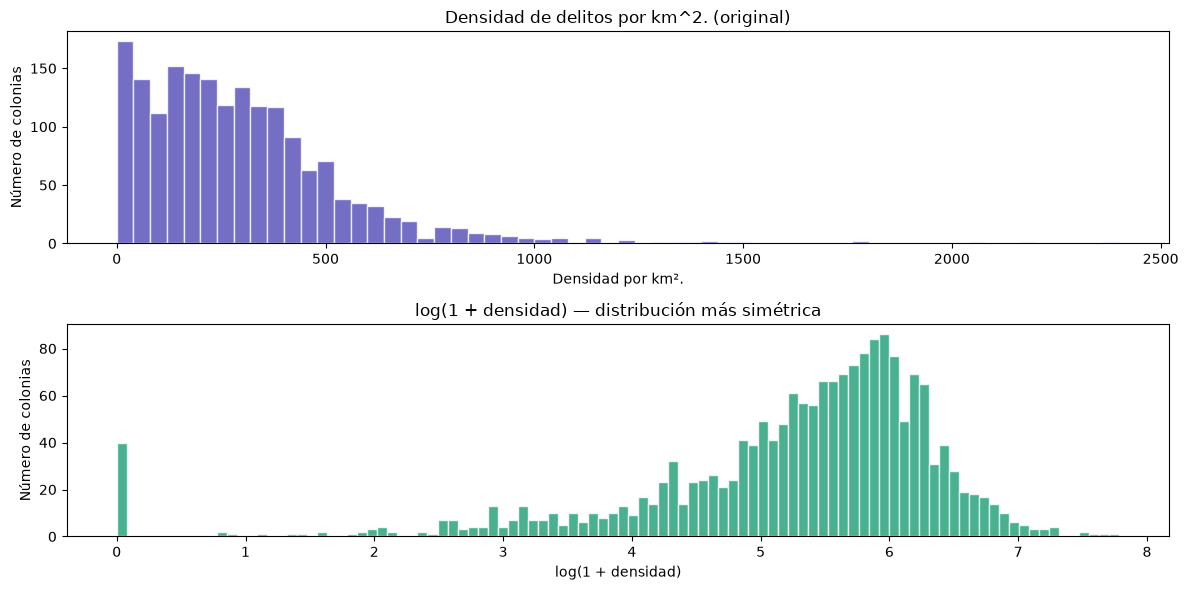

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Histograma tasa cruda
axes[0].hist(demografico_clean['dens_delitos_km2'].dropna(), bins=60, color='#534AB7', alpha=0.8, edgecolor='white')
axes[0].set_title('Densidad de delitos por km^2. (original)', fontsize=12)
axes[0].set_xlabel('Densidad por km².')
axes[0].set_ylabel('Número de colonias')

# Log-tasa (más simétrica)
axes[1].hist(demografico_clean['log_dens_delitos'].dropna(), bins=100, color='#1D9E75', alpha=0.8, edgecolor='white')
axes[1].set_title('log(1 + densidad) — distribución más simétrica', fontsize=12)
axes[1].set_xlabel('log(1 + densidad)')
axes[1].set_ylabel('Número de colonias')

plt.tight_layout()
plt.savefig('resultados/01_descriptivas.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.7.2 Estadisticas descriptivas

In [23]:
estadisticas_descriptivas = demografico_clean[
    ['tasa_100k', 'dens_pob_km2', 'dens_delitos_km2', 'log_tasa', 'log_dens_pob', 'log_dens_delitos']
].describe().round(2)

print("=== Estadísticas descriptivas — variables principales ===\n")
display(estadisticas_descriptivas)

=== Estadísticas descriptivas — variables principales ===



,tasa_100k,dens_pob_km2,dens_delitos_km2,log_tasa,log_dens_pob,log_dens_delitos
count,1814.00,1814.00,1814.00,1814.00,1814.00,1814.00
mean,2686.47,18043.50,296.40,7.21,9.50,5.23
std,13282.93,13233.22,243.52,1.40,0.90,1.26
min,0.00,41.19,0.00,0.00,3.74,0.00
25%,955.88,9094.35,127.83,6.86,9.12,4.86
50%,1574.47,16206.02,252.58,7.36,9.69,5.54
75%,2589.40,23729.64,402.07,7.86,10.07,6.00
max,512500.00,123305.92,2400.62,13.15,11.72,7.78


### 1.8 Extraccion Numero de camaras por colonia

In [24]:
camaras.head(3)

,id stv,calle,esquina / entre calles,alcaldia,cve_col,colonia,latitud,longitud,geometry
0,4401,ABRAHAM LINCOLN,JOHN TAYLOR,ALVARO OBREGON,10-178,PRESIDENTES 1RA (AMPL),19.376046,-99.226281,POINT (476237.911 2142452.529)
1,6322,EISENHOWER,KENNEDY,ALVARO OBREGON,10-178,PRESIDENTES 1RA (AMPL),19.375733,-99.224345,POINT (476441.169 2142417.629)
2,12515,GUSTAVO DIAZ ORDAZ,ROOSVELT,ALVARO OBREGON,10-178,PRESIDENTES 1RA (AMPL),19.374707,-99.223498,POINT (476529.967 2142303.984)


In [25]:
# buscar vacio en camaras
camaras.isnull().sum()

id stv                     0
calle                      0
esquina / entre calles     5
alcaldia                  35
cve_col                   35
colonia                   35
latitud                    0
longitud                   0
geometry                   0
dtype: int64

Hay datos vacios, por lo que usamos "geometry" para calzar con la colonia

In [26]:
cols_a_eliminar = ['n_camaras', 'dens_camaras_km2']
demografico_clean = demografico_clean.drop(
    columns=[c for c in cols_a_eliminar if c in demografico_clean.columns]
)

# Asegurarse que ambos GeoDataFrames tienen el mismo CRS
print(f"CRS cámaras:  {camaras.crs}")
print(f"CRS colonias: {demografico_clean.crs}")

# Si son distintos, reproyectar cámaras al CRS de colonias
camaras_proj = camaras.to_crs(demografico_clean.crs)

# Spatial join: asignar cada cámara a la colonia que la contiene
camaras_en_colonia = gpd.sjoin(
    camaras_proj[['id stv', 'geometry']],  # solo necesitamos el id y geometría
    demografico_clean[['cve_col', 'geometry']],
    how='inner',          # solo cámaras que caen dentro de alguna colonia
    predicate='within'    # la cámara está dentro del polígono de la colonia
)

# Contar cámaras por colonia
n_camaras = (
    camaras_en_colonia
    .groupby('cve_col')
    .size()
    .reset_index(name='n_camaras')
)

# Unir al dataset principal
demografico_clean = demografico_clean.merge(n_camaras, on='cve_col', how='left')

# Las colonias sin cámaras quedan NaN → 0
demografico_clean['n_camaras'] = demografico_clean['n_camaras'].fillna(0)

# Densidad de cámaras por km²
demografico_clean['dens_camaras_km2'] = (
    demografico_clean['n_camaras'] / demografico_clean['area_km2']
)

print(f"Total cámaras asignadas: {n_camaras['n_camaras'].sum():.0f}")
print(f"Cámaras sin colonia asignada: {len(camaras_proj) - n_camaras['n_camaras'].sum():.0f}")
print(f"Colonias con al menos 1 cámara: {(demografico_clean['n_camaras'] > 0).sum()}")
print(f"Colonias sin cámaras: {(demografico_clean['n_camaras'] == 0).sum()}")
demografico_clean[['colonia', 'n_camaras', 'dens_camaras_km2']].head(5)

CRS cámaras:  EPSG:32614
CRS colonias: EPSG:32614
Total cámaras asignadas: 14710
Cámaras sin colonia asignada: 35
Colonias con al menos 1 cámara: 1580
Colonias sin cámaras: 234


,colonia,n_camaras,dens_camaras_km2
0,AGUILERA,5.0,48.157958
1,ALDANA,8.0,51.675581
2,ANGEL ZIMBRON,8.0,33.026190
3,ARENAL,8.0,27.964695
4,CENTRO DE AZCAPOTZALCO,21.0,49.473344


### 1.9 Extraccion numero de aglomeraciones por colonia

In [27]:
aglomeraciones.head(3)

,id,nom_estab,nombre_act,alcaldia,cve_col,colonia,latitud,longitud,cat_act,geometry
0,742945,20 ABARROTES DON ARMANDO,"Comercio al por menor en tiendas de abarrotes,...",AZCAPOTZALCO,02-113,PRO HOGAR I,19.475885,-99.153945,Comercio al por menor,POINT (483843.858 2153491.724)
1,9041142,2 X U,Comercio al por menor de artículos y aparatos ...,CUAJIMALPA DE MORELOS,04-012,CORREDOR SANTA FE,19.362629,-99.274433,Comercio al por menor,POINT (471179.039 2140975.175)
2,8332695,2000_CVS BIM CENTENARIO,Comercio al por menor de otros alimentos,ALVARO OBREGON,10-235,VALENTIN GOMEZ FARIAS,19.357338,-99.235560,Comercio al por menor,POINT (475260.681 2140383.783)


In [28]:
# buscar vacio en camaras
aglomeraciones.isnull().sum()

id              0
nom_estab       0
nombre_act      0
alcaldia      205
cve_col       205
colonia       205
latitud         0
longitud        0
cat_act         0
geometry        0
dtype: int64

Hay datos vacios, por lo que usamos "geometry" para calzar con la colonia, ya que esta vacia, si no lo estuviera el cruce seria altiro.

In [29]:
# Eliminar columnas si ya existen (por re-ejecución)
cols_aglom = ['n_aglom', 'dens_aglom_km2'] + \
             [f'n_aglom_{c[:15]}' for c in aglomeraciones['cat_act'].unique()]
demografico_clean = demografico_clean.drop(
    columns=[c for c in cols_aglom if c in demografico_clean.columns]
)

# Reproyectar al mismo CRS
aglomeraciones_proj = aglomeraciones.to_crs(demografico_clean.crs)

# Spatial join: asignar cada aglomeración a su colonia por geometría
aglom_en_colonia = gpd.sjoin(
    aglomeraciones_proj[['id', 'cat_act', 'geometry']],
    demografico_clean[['cve_col', 'geometry']],
    how='inner',
    predicate='within'
)

# ── Variable 1: total de aglomeraciones por colonia ───────────────────────────
n_aglom_total = (
    aglom_en_colonia
    .groupby('cve_col')
    .size()
    .reset_index(name='n_aglom')
)

demografico_clean = demografico_clean.merge(n_aglom_total, on='cve_col', how='left')
demografico_clean['n_aglom'] = demografico_clean['n_aglom'].fillna(0)
demografico_clean['dens_aglom_km2'] = demografico_clean['n_aglom'] / demografico_clean['area_km2']

# ── Variable 2: conteo por categoría ─────────────────────────────────────────
n_aglom_cat = (
    aglom_en_colonia
    .groupby(['cve_col', 'cat_act'])
    .size()
    .reset_index(name='n')
    .pivot_table(index='cve_col', columns='cat_act', values='n', fill_value=0)
    .reset_index()
)

# Renombrar columnas para que sean más manejables
n_aglom_cat.columns.name = None
n_aglom_cat = n_aglom_cat.rename(columns={
    c: f'n_aglom_{c[:15].strip()}' 
    for c in n_aglom_cat.columns if c != 'cve_col'
})

demografico_clean = demografico_clean.merge(n_aglom_cat, on='cve_col', how='left')

# Rellenar NaN con 0 en columnas de categorías
cols_cat = [c for c in demografico_clean.columns if c.startswith('n_aglom_')]
demografico_clean[cols_cat] = demografico_clean[cols_cat].fillna(0)

print(f"Total aglomeraciones asignadas: {n_aglom_total['n_aglom'].sum():.0f}")
print(f"Sin colonia asignada: {len(aglomeraciones_proj) - n_aglom_total['n_aglom'].sum():.0f}")
print(f"Colonias con al menos 1 aglomeración: {(demografico_clean['n_aglom'] > 0).sum()}")
print(f"Colonias sin aglomeraciones: {(demografico_clean['n_aglom'] == 0).sum()}")
print(f"\nColumnas de categorías creadas:")
print(cols_cat)

Total aglomeraciones asignadas: 251687
Sin colonia asignada: 205
Colonias con al menos 1 aglomeración: 1774
Colonias sin aglomeraciones: 40

Columnas de categorías creadas:
['n_aglom_Actividades cul', 'n_aglom_Asociaciones re', 'n_aglom_Bancas y cajero', 'n_aglom_Comercio al por', 'n_aglom_Escuelas', 'n_aglom_Instituciones d', 'n_aglom_Transportes']


In [30]:
demografico_clean.columns

Index(['alcaldia', 'cve_col', 'colonia', 'geometry', 'n_delitos', 'pob_2010',
       'SUP_COL_M2', 'VIV2010', 'DENVIVHa', 'n_HOMICIDIO_DOLOSO',
       'n_LESIONES_DOLOSAS_POR_DISPARO_D', 'n_ROBO_A_CASA_HABITACIÓN_CON_VIO',
       'n_ROBO_A_CUENTAHABIENTE_SALIENDO', 'n_ROBO_A_NEGOCIO_CON_VIOLENCIA',
       'n_ROBO_A_PASAJERO_A_BORDO_DE_MIC', 'n_ROBO_A_PASAJERO_A_BORDO_DE_TAX',
       'n_ROBO_A_PASAJERO_A_BORDO_DEL_ME', 'n_ROBO_A_REPARTIDOR_CON_Y_SIN_VI',
       'n_ROBO_A_TRANSEUNTE_EN_VÍA_PÚBLI', 'n_ROBO_A_TRANSPORTISTA_CON_Y_SIN',
       'n_ROBO_DE_VEHÍCULO_CON_Y_SIN_VIO', 'n_SECUESTRO', 'n_VIOLACIÓN',
       'area_km2', 'tasa_100k', 'dens_delitos_km2', 'dens_pob_km2', 'log_tasa',
       'log_dens_pob', 'log_dens_delitos', 'tasa_ROBO A TRANSEUNTE EN',
       'tasa_ROBO DE VEHÍCULO CON', 'tasa_ROBO A NEGOCIO CON V',
       'tasa_ROBO A REPARTIDOR CO', 'tasa_VIOLACIÓN', 'n_camaras',
       'dens_camaras_km2', 'n_aglom', 'dens_aglom_km2',
       'n_aglom_Actividades cul', 'n_aglom_Asociac

### 2 Exportacion

Los tres datasets resultantes se guardan en formato GeoPackage en la carpeta resultados. El notebook de analisis cargara directamente desde estos archivos.

- `incidencias.gpkg`: puntos de delito limpios (189,435 registros).
- `colonias.gpkg`: polígonos de colonias sin registros nulos (1,814 colonias).
- `demografico.gpkg`: dataset analítico completo con variables demográficas, conteos por categoria, densidades, transformaciones logaritmicas, camaras y aglomeraciones.
- `conteo_anual.gpkg`: dataset con una fila por colonia × año × categoría de delito (149,016 filas). Permite analizar la evolución temporal del crimen entre 2019 y 2024.


In [32]:
# ==========================================
# EXPORTAR RESULTADOS
# ==========================================

carpeta = "resultados"

import os
os.makedirs(carpeta, exist_ok=True)

# Guardar incidencias finales (puntos)
incidencias_final.to_file(f"{carpeta}/incidencias.gpkg", driver="GPKG")

# Guardar colonias (polígonos limpios)
colonias_base.to_file(f"{carpeta}/colonias.gpkg", driver="GPKG")

# Guardar dataset final consolidado (polígonos con datos demográficos y delitos)
demografico_clean.to_file(f"{carpeta}/demografico.gpkg", driver="GPKG")

# Guardar dataset longitudinal (colonia × año × categoría)
conteo_anual_gdf = gpd.GeoDataFrame(conteo_anual, geometry='geometry', crs=demografico_clean.crs)
conteo_anual_gdf.to_file(f"{carpeta}/conteo_anual.gpkg", driver="GPKG")

print("Archivos exportados correctamente")

Archivos exportados correctamente
